In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df=pd.read_csv(r"C:\Users\hi\OneDrive\Documents\Working\dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt

In [12]:
import seaborn as sns

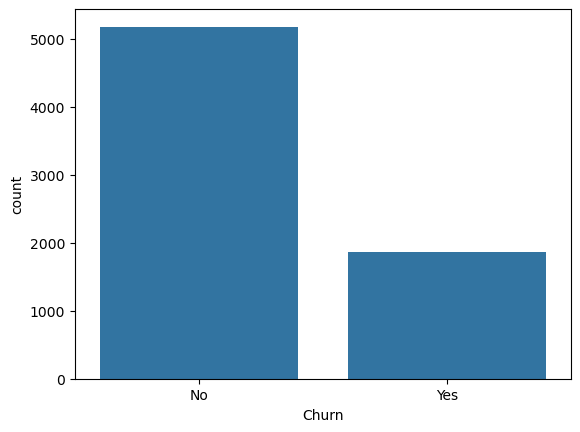

In [13]:
sns.countplot(x='Churn', data=df)
plt.show()

In [14]:
df.drop("customerID", axis=1, inplace=True)

In [15]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

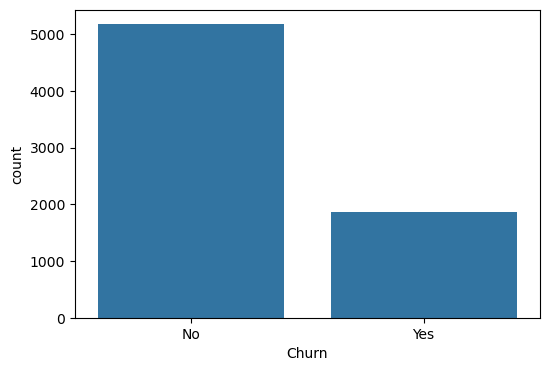

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.show()

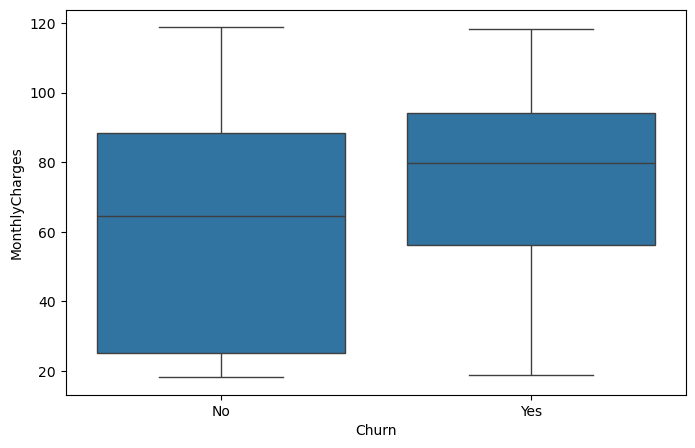

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)
plt.show()

In [19]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

In [ ]:
"""
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import GridSearchCV"""

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [22]:
y = df["Churn"]

In [23]:
X = df.drop("Churn", axis=1)

In [31]:
y = y[X.notna().all(axis=1)]
X = X.dropna()

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [38]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [39]:
accuracy_score(y_test, pred_lr)

0.7938877043354655

In [40]:
cm = confusion_matrix(
    y_test,
    pred_lr
)

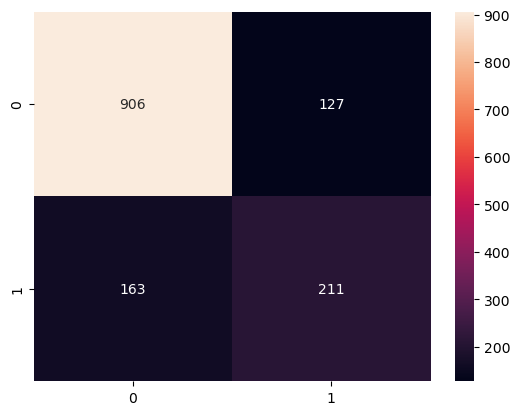

In [41]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.show()

In [42]:
print(
    classification_report(
        y_test,
        pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



In [43]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
from sklearn.ensemble import GradientBoostingClassifier

In [48]:
models = {
    "Logistic Regression":
    LogisticRegression(),
    "Decision Tree":
    DecisionTreeClassifier(),
    "Random Forest":
    RandomForestClassifier(),
    "Gradient Boosting":
    GradientBoostingClassifier()
}

In [49]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(
        y_test,
        pred
    )
    results[name] = acc
results

{'Logistic Regression': 0.7938877043354655,
 'Decision Tree': 0.7313432835820896,
 'Random Forest': 0.7853589196872779,
 'Gradient Boosting': 0.7974413646055437}

In [50]:
pd.DataFrame(
    results.items(),
    columns=["Model","Accuracy"]
).sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,Gradient Boosting,0.797441
0,Logistic Regression,0.793888
2,Random Forest,0.785359
1,Decision Tree,0.731343


In [51]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None],
    "min_samples_split":[2,5]
}

In [53]:
from sklearn.model_selection import GridSearchCV

In [54]:
grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [55]:
from sklearn.model_selection import GridSearchCV

In [56]:
best_model = grid.best_estimator_

In [57]:
accuracy_score(y_test, pred)

0.7974413646055437

In [58]:
probs = best_model.predict_proba(X_test)[:,1]

In [59]:
roc_auc_score(
    y_test,
    probs
)

0.8273640970953197

In [60]:
fpr,tpr,_ = roc_curve(
    y_test,
    probs
)

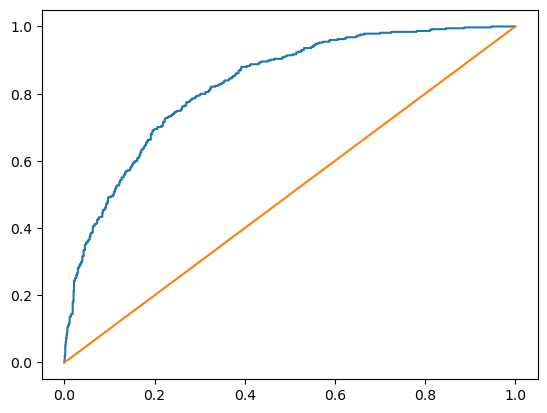

In [61]:
plt.plot(fpr,tpr)
plt.plot(
    [0,1],
    [0,1]
)
plt.show()

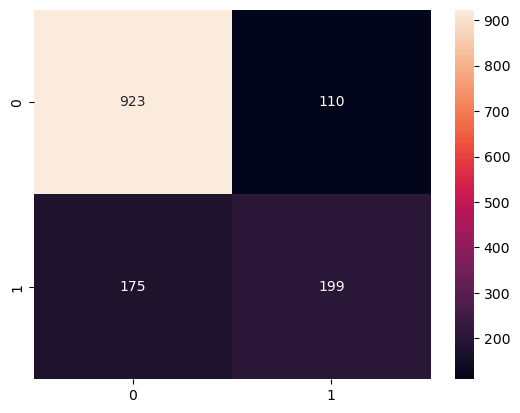

In [62]:
cm = confusion_matrix(
    y_test,
    pred
)
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.show()

In [63]:
importance = pd.DataFrame({
    "Feature": X.columns,

    "Importance":
    best_model.feature_importances_
})

In [64]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

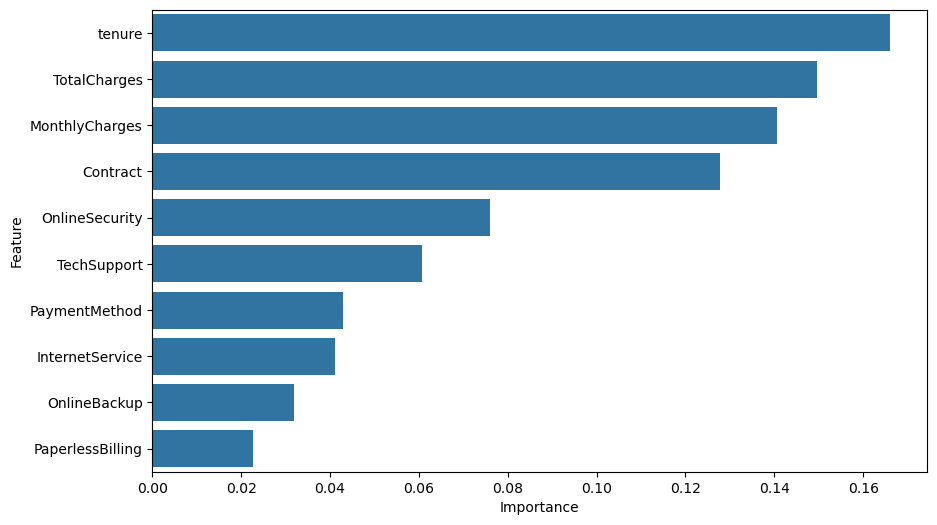

In [65]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)
plt.show()